# South Australia Electricity — LSTM Forecasting

## Role
This notebook evaluates a supervised recurrent neural forecasting model (LSTM) against
the transparent classical/statistical benchmark floor established in
`11_Electricity_Classical_Baselines.ipynb`.

## Inputs
- The canonical South Australia half-hourly demand series and frozen Development /
  Validation / Pre-test / Test partitions (reconstructed once here, same reconstruction
  rule as every other Electricity notebook).
- Saved classical benchmark forecast artifacts
  (`results/electricity/protocol_a/b_baseline_forecasts.csv`,
  `protocol_a/b_dhr_forecast.csv`).
- Existing LSTM forecast artifacts (`results/electricity/protocol_a_lstm_forecast.csv`,
  `protocol_b_lstm_forecast.csv`).

## Outputs
Validation-only context-selection evidence, Protocol A LSTM forecast evidence, Protocol B
direct 48-step LSTM evidence, horizon-specific evaluation, residual diagnostics,
benchmark-relative interpretation, and a reproducibility record. By default this notebook
does not retrain any model or overwrite any authoritative artifact; it only writes
candidate forecast CSVs -- to a staging directory, never to the authoritative
`results/electricity/` files -- if a person explicitly sets `RUN_FITTING = True`
(Section 2).

## Depends On
`10_Electricity_EDA.ipynb`, `11_Electricity_Classical_Baselines.ipynb`

## Authoritative Status
`AUTHORITATIVE ELECTRICITY SUPERVISED LSTM EVALUATION`

## What This Notebook Does Not Do
This notebook does NOT:
- evaluate any foundation model (`13_Electricity_Foundation_Models.ipynb`)
- compute final Trust Scores or trustworthiness synthesis
  (`17_Electricity_Trustworthiness.ipynb`)
- perform final statistical-significance analysis
  (`18_Electricity_Statistical_Significance.ipynb`)
- perform any cross-domain comparison

## 1. Objective and Research Questions

> Does a supervised LSTM trained only on historical South Australia demand improve
> meaningfully over transparent deterministic and statistical forecasting systems under
> both short-horizon and full-day forecasting?

### Q1 — Context Length
> How much history should the LSTM observe before forecasting?

### Q2 — Protocol A
> Can the LSTM improve on persistence and classical statistical systems when forecasting
> the next half-hour?

### Q3 — Protocol B
> Can a direct 48-output LSTM preserve accuracy across a full 24-hour day-ahead horizon?

### Q4 — Complexity vs Benefit
> Does the additional representational and computational complexity of the LSTM provide a
> meaningful forecasting advantage over simpler systems?

This framing matters because the results do **not** automatically show that the neural
model wins -- `11_Electricity_Classical_Baselines.ipynb` established a strong classical
floor (SARIMA best under both protocols), and this notebook tests the LSTM against that
floor rather than assuming its superiority.

## 2. Setup

**This notebook is computationally expensive and, with the historical settings, retrains
the LSTM on every `Run All`.** The validation-only context-selection grid alone
(Section 5) took approximately 36 minutes in the run that produced the current frozen
forecast artifacts. Both `protocol_a_lstm_forecast.csv` and `protocol_b_lstm_forecast.csv`
already exist and provide sufficient frozen evidence for artifact-only analysis, so this
notebook introduces the same safe execution-policy pattern as
`11_Electricity_Classical_Baselines.ipynb`:

```
RUN_SELECTION = False   # if True, reruns the ~36-minute validation-only context grid (Section 5)
RUN_FITTING   = False   # if True, retrains the final Protocol A and Protocol B models (~1 minute total)
```

By default (both `False`), this notebook loads the already-saved forecast CSVs and the
historically-selected context/epoch configuration, and performs no training. Setting
either flag to `True` reruns that specific piece of work from scratch. Even with
`RUN_FITTING=True`, regenerated forecasts are written only to
`results/electricity/staging/`, never to the authoritative `results/electricity/` files.
The validation-selection grid itself (Section 5) has no persisted machine-readable
artifact -- unlike DHR-ARIMA's grid in Notebook 11, it is not even redisplayed as a frozen
literal table here; only the resulting selected scalars (context, best epoch) are
retained, with honest provenance (Section 5.2).

In [1]:
from pathlib import Path
import os, sys, time, random, platform
os.environ["PYTHONHASHSEED"] = "42"; os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"; os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from IPython.display import display

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate project root containing src/")

ROOT = find_project_root(Path.cwd())
RESULTS = ROOT / "results/electricity"
STAGING = RESULTS / "staging"  # RUN_FITTING candidate output only; never the authoritative directory
DATA = ROOT / "data/electricity/australian_electricity_demand_dataset.tsf"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.metrics import mae, rmse, mape, smape

RUN_SELECTION = False   # if True, reruns the ~36-minute validation-only context grid (Section 5)
RUN_FITTING = False     # if True, retrains the final Protocol A and Protocol B models (~1 minute total)
display(pd.Series({"RUN_SELECTION": RUN_SELECTION, "RUN_FITTING": RUN_FITTING}, name="Execution policy").to_frame())

,Execution policy
RUN_SELECTION,False
RUN_FITTING,False


## 3. Data and Frozen Experimental Design

### 3.1 Frozen Partitions

In [2]:
def load_tsf(path):
    attrs, rows = [], []
    with Path(path).open(encoding="utf-8") as f:
        for raw in f:
            line = raw.strip()
            if not line or line.startswith("#"):
                continue
            if line.startswith("@attribute"):
                _, n, k = line.split(maxsplit=2); attrs.append((n, k))
            elif not line.startswith("@"):
                p = line.split(":", len(attrs)); r = dict(zip((a[0] for a in attrs), p[:-1]))
                r["series_value"] = np.fromstring(p[-1], sep=","); rows.append(r)
    return pd.DataFrame(rows)

raw = load_tsf(DATA)
row = raw[(raw.series_name == "T4") & (raw.state == "SA")].iloc[0]
idx = pd.date_range(pd.to_datetime(row.start_timestamp, format="%Y-%m-%d %H-%M-%S"), periods=len(row.series_value), freq="30min")
y = pd.Series(row.series_value, index=idx, name="Demand")
assert row.series_name == "T4" and row.state == "SA" and len(y) == 230784 and pd.infer_freq(y.index) == "30min"

dev = y.loc[:"2011-06-23 23:30"]; val = y.loc["2011-06-24":"2012-07-12 23:30"]; pre = y.loc[:"2012-07-12 23:30"]; test = y.loc["2012-07-13":]
assert (len(dev), len(val), len(pre), len(test)) == (166128, 18480, 184608, 46176)
scale_dev = np.mean(np.abs(dev.to_numpy()[48:] - dev.to_numpy()[:-48]))
scale_final = np.mean(np.abs(pre.to_numpy()[48:] - pre.to_numpy()[:-48]))
assert np.isclose(scale_final, 117.057971280678, atol=1e-9)

partition_table = pd.DataFrame({
    "Partition": ["Development", "Validation", "Pre-test", "Test"],
    "Start": [z.index[0] for z in [dev, val, pre, test]],
    "End": [z.index[-1] for z in [dev, val, pre, test]],
    "Observations": [len(z) for z in [dev, val, pre, test]],
    "Role": ["Context/model selection", "Early stopping / context selection", "Final model training", "Frozen final evaluation"],
})
display(partition_table)

,Partition,Start,End,Observations,Role
0,Development,2002-01-01,2011-06-23 23:30:00,166128,Context/model selection
1,Validation,2011-06-24,2012-07-12 23:30:00,18480,Early stopping / context selection
2,Pre-test,2002-01-01,2012-07-12 23:30:00,184608,Final model training
3,Test,2012-07-13,2015-03-01 23:30:00,46176,Frozen final evaluation


### 3.2 Protocol A — Next Half-Hour Forecasting

In [3]:
protocol_a_table = pd.DataFrame([
    {"Property": "Horizon", "Value": 1},
    {"Property": "Frequency", "Value": "30 minutes"},
    {"Property": "Output dimension", "Value": 1},
    {"Property": "Actual update between origins", "Value": "Yes"},
    {"Property": "Information boundary", "Value": "History strictly before the target"},
])
display(protocol_a_table)

,Property,Value
0,Horizon,1
1,Frequency,30 minutes
2,Output dimension,1
3,Actual update between origins,Yes
4,Information boundary,History strictly before the target


This is a sequential next-step task: at each origin the model observes a fixed-length
history window ending strictly before the target, and the next actual becomes available
before the *next* origin's forecast.

### 3.3 Protocol B — Direct Day-Ahead Forecasting

In [4]:
protocol_b_table = pd.DataFrame([
    {"Property": "Horizon", "Value": 48},
    {"Property": "Duration", "Value": "24 hours"},
    {"Property": "Output dimension", "Value": 48},
    {"Property": "Origins", "Value": "Midnight / complete-day origins"},
    {"Property": "Actual updates inside block", "Value": "No"},
    {"Property": "Forecast strategy", "Value": "Direct multi-output (Dense(48), one model call per origin)"},
])
display(protocol_b_table)

,Property,Value
0,Horizon,48
1,Duration,24 hours
2,Output dimension,48
3,Origins,Midnight / complete-day origins
4,Actual updates inside block,No
5,Forecast strategy,"Direct multi-output (Dense(48), one model call..."


Protocol B is **not** 48 stitched one-step predictions; a single model call produces all
48 outputs simultaneously from one context window, with no actual observed during the
target day used to revise any of the 48 outputs (Section 7.1).

### 3.4 Scaling and Information Boundaries

Two separate scaler stages exist, each with a distinct fitting boundary and purpose.

In [5]:
class StandardScaler1D:
    def fit(self, a):
        self.mean_ = float(np.mean(a)); self.scale_ = float(np.std(a)); return self
    def transform(self, a):
        return (np.asarray(a, float) - self.mean_) / self.scale_
    def inverse_transform(self, a):
        return np.asarray(a, float) * self.scale_ + self.mean_

dev_scaler = StandardScaler1D().fit(dev)
final_scaler = StandardScaler1D().fit(pre)
assert np.allclose(dev_scaler.inverse_transform(dev_scaler.transform(dev)), dev)
assert np.allclose(final_scaler.inverse_transform(final_scaler.transform(pre)), pre)

scaling_table = pd.DataFrame([
    {"Stage": "Context selection", "Scaler Fit Data": "Development only", "Used For": "Model/context selection (Section 5)", "Test Information Used?": "No"},
    {"Stage": "Final training", "Scaler Fit Data": "Complete Pre-test only", "Used For": "Final Protocol A/B LSTM (Sections 6-7)", "Test Information Used?": "No"},
])
display(scaling_table)

,Stage,Scaler Fit Data,Used For,Test Information Used?
0,Context selection,Development only,Model/context selection (Section 5),No
1,Final training,Complete Pre-test only,Final Protocol A/B LSTM (Sections 6-7),No


Neither scaler is ever fit on validation or test data -- the selection scaler sees only
Development, and the final scaler sees only Pre-test (Development + Validation combined),
never Test. This mirrors the leakage discipline established for every classical model in
Notebook 11.

## 4. LSTM Model Design

### 4.1 Input Representation

The model is univariate: it observes only standardized past South Australia demand
values (Section 3.4), with no exogenous covariates (weather, calendar, price). The
input to each forecast is a fixed-length sequence of `context` scaled half-hourly demand
values; the output is inverse-scaled back to original demand units (MW) before any metric
is computed, so every reported error is in real demand units, not standardized units.

### 4.2 Architecture

Both protocols share the same `LSTM(64) -> Dense(32, ReLU) -> Dense(output)` backbone;
only the final output dimension differs.

```
Input sequence (context, 1)
      |
      v
  LSTM(64 units)
      |
      v
  Dense(32, ReLU)
      |
      v
  Dense(output)   <- output=1 for Protocol A, output=48 for Protocol B
```

In [6]:
architecture_table = pd.DataFrame([
    {"Layer": "Input", "Protocol A": "(context, 1)", "Protocol B": "(context, 1)"},
    {"Layer": "LSTM", "Protocol A": "64 units", "Protocol B": "64 units"},
    {"Layer": "Dense hidden", "Protocol A": "32 units, ReLU", "Protocol B": "32 units, ReLU"},
    {"Layer": "Output", "Protocol A": "1", "Protocol B": "48"},
])
display(architecture_table)

,Layer,Protocol A,Protocol B
0,Input,"(context, 1)","(context, 1)"
1,LSTM,64 units,64 units
2,Dense hidden,"32 units, ReLU","32 units, ReLU"
3,Output,1,48


### 4.3 Training Configuration

Every value below is read directly from the model-building and training code (Section
5), not guessed.

In [7]:
training_config_table = pd.DataFrame([
    {"Hyperparameter": "Candidate contexts", "Value": "48, 336, 672"},
    {"Hyperparameter": "Training stride", "Value": 12},
    {"Hyperparameter": "Batch size", "Value": 256},
    {"Hyperparameter": "Maximum epochs", "Value": 20},
    {"Hyperparameter": "Early-stopping patience", "Value": 3},
    {"Hyperparameter": "Optimizer", "Value": "Adam (Keras default learning rate; not explicitly overridden in code)"},
    {"Hyperparameter": "Loss", "Value": "MSE"},
    {"Hyperparameter": "Shuffle", "Value": False},
    {"Hyperparameter": "Random seed", "Value": 42},
])
display(training_config_table)

,Hyperparameter,Value
0,Candidate contexts,"48, 336, 672"
1,Training stride,12
2,Batch size,256
3,Maximum epochs,20
4,Early-stopping patience,3
5,Optimizer,Adam (Keras default learning rate; not explici...
6,Loss,MSE
7,Shuffle,False
8,Random seed,42


### 4.4 Determinism Controls

In [8]:
SEED = 42; random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
determinism_note = "Yes"
try:
    tf.config.experimental.enable_op_determinism()
except Exception as exc:
    determinism_note = f"Requested, but raised: {exc}"

gpu_devices = tf.config.list_physical_devices("GPU")
determinism_table = pd.DataFrame([
    {"Item": "Python version", "Value": sys.version.split()[0]},
    {"Item": "TensorFlow version", "Value": tf.__version__},
    {"Item": "Seed", "Value": SEED},
    {"Item": "shuffle", "Value": False},
    {"Item": "TensorFlow deterministic ops requested", "Value": determinism_note},
    {"Item": "Device", "Value": platform.processor() or platform.machine()},
    {"Item": "GPU used", "Value": "Yes" if gpu_devices else "No"},
])
display(determinism_table)

,Item,Value
0,Python version,3.13.2
1,TensorFlow version,2.21.0
2,Seed,42
3,shuffle,False
4,TensorFlow deterministic ops requested,Yes
5,Device,"AMD64 Family 25 Model 80 Stepping 0, AuthenticAMD"
6,GPU used,No


Determinism is *requested* here (seeded RNGs, `TF_DETERMINISTIC_OPS=1`,
`enable_op_determinism()`, `shuffle=False`); this notebook does not claim bit-identical
independent reruns beyond what Section 10's reproducibility record documents evidence for.

## 5. Validation-Only Context Selection

### 5.1 Candidate Contexts

Sensible candidates given `10_Electricity_EDA.ipynb`'s seasonality evidence (strong
lag-48 and lag-336 autocorrelation).

In [9]:
CONTEXTS = [48, 336, 672]
context_interpretation = pd.DataFrame([
    {"Context": 48, "Interpretation": "One daily cycle"},
    {"Context": 336, "Interpretation": "One weekly cycle"},
    {"Context": 672, "Interpretation": "Two weekly cycles"},
])
display(context_interpretation)

,Context,Interpretation
0,48,One daily cycle
1,336,One weekly cycle
2,672,Two weekly cycles


### 5.2 Selection Results

**Provenance note:** the full 3-context validation grid (per-context training anchors,
epochs, losses, and validation metrics) has no persisted machine-readable artifact and
takes approximately 36 minutes to reproduce -- too expensive to run on every default
execution. Consistent with `11_Electricity_Classical_Baselines.ipynb`'s DHR-ARIMA
provenance pattern (Section 2.3 there), the selected scalars are retained as a **frozen
research decision** rather than the full grid being redisplayed as a hard-coded literal
table. `RUN_SELECTION=True` reproduces the complete grid, training histories, and
selection metrics dynamically from preserved development/validation data.

In [10]:
TRAIN_STRIDE = 12; BATCH = 256; MAX_EPOCHS = 20; PATIENCE = 3
FROZEN_SELECTED_CONTEXT = 48  # historical validation-selected value; grid not persisted as an artifact
FROZEN_BEST_EPOCH_A = 5       # historical best epoch at the selected context, Protocol A selection run

def reset_seed():
    random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED); tf.keras.backend.clear_session()

def dataset(values, targets, context, horizon, batch=BATCH):
    a = tf.constant(np.asarray(values, np.float32))
    ids = tf.data.Dataset.from_tensor_slices(np.asarray(targets, np.int64))
    def take(i):
        return tf.expand_dims(a[i - context:i], -1), a[i:i + horizon] if horizon > 1 else a[i]
    ds = ids.map(take, num_parallel_calls=1).batch(batch).prefetch(1)
    opt = tf.data.Options(); opt.experimental_deterministic = True
    return ds.with_options(opt)

def build_model(context, horizon):
    reset_seed()
    model = tf.keras.Sequential([
        tf.keras.layers.Input((context, 1)), tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(32, activation="relu"), tf.keras.layers.Dense(horizon),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(), loss="mse")
    return model

def metric_row(a, p, scale):
    return {"MAE": mae(a, p), "RMSE": rmse(a, p), "MAPE": mape(a, p), "sMAPE": smape(a, p), "MASE_48": mae(a, p) / scale}

if RUN_SELECTION:
    selection_rows = []; histories = {}; selection_start = time.perf_counter()
    for context in CONTEXTS:
        tr_idx = np.arange(context, len(dev), TRAIN_STRIDE); va_idx = np.arange(len(dev), len(pre))
        model = build_model(context, 1)
        cb = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
        hist = model.fit(dataset(dev_scaler.transform(dev), tr_idx, context, 1),
                          validation_data=dataset(dev_scaler.transform(pre), va_idx, context, 1),
                          epochs=MAX_EPOCHS, shuffle=False, callbacks=[cb], verbose=0)
        pred = dev_scaler.inverse_transform(model.predict(dataset(dev_scaler.transform(pre), va_idx, context, 1), verbose=0).reshape(-1))
        rowm = metric_row(val, pred, scale_dev)
        selection_rows.append({"Context": context, "Train_Anchors": len(tr_idx), "Validation_N": len(va_idx),
                                "Epochs": len(hist.history["loss"]), "Best_Epoch": int(np.argmin(hist.history["val_loss"]) + 1),
                                "Final_Train_Loss": hist.history["loss"][-1], "Best_Val_Loss": min(hist.history["val_loss"]), **rowm})
        histories[context] = hist.history
    selection_runtime = time.perf_counter() - selection_start
    selection = pd.DataFrame(selection_rows).sort_values("MASE_48").reset_index(drop=True)
    display(selection)
    CONTEXT = int(selection.iloc[0].Context); BEST_EPOCH_A = int(selection.iloc[0].Best_Epoch)
    assert CONTEXT == FROZEN_SELECTED_CONTEXT and BEST_EPOCH_A == FROZEN_BEST_EPOCH_A
    print(f"Selected context {CONTEXT}, best epoch {BEST_EPOCH_A}, selection runtime {selection_runtime:.1f}s")
else:
    CONTEXT = FROZEN_SELECTED_CONTEXT; BEST_EPOCH_A = FROZEN_BEST_EPOCH_A; histories = None
    display(pd.DataFrame([{"Property": "Selected context", "Value": CONTEXT}, {"Property": "Best epoch (Protocol A selection)", "Value": BEST_EPOCH_A},
                          {"Property": "Source", "Value": "Frozen selected configuration (selection grid not persisted as an artifact; RUN_SELECTION=True reproduces it)"}]))

,Property,Value
0,Selected context,48
1,Best epoch (Protocol A selection),5
2,Source,Frozen selected configuration (selection grid ...


### 5.3 Context-Selection Visualisation

In [11]:
if RUN_SELECTION:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(selection.Context.astype(str), selection.MASE_48, color="#546e7a")
    ax.set(title="Validation MASE-48 by candidate context", xlabel="Context (half-hours)", ylabel="Validation MASE-48")
    ax.grid(axis="y", alpha=0.25); plt.tight_layout(); plt.show()
else:
    print("Not recomputed by default (RUN_SELECTION=False) -- no per-context validation metrics are available "
          "without rerunning the grid (Section 5.2). RUN_SELECTION=True reproduces this chart.")

Not recomputed by default (RUN_SELECTION=False) -- no per-context validation metrics are available without rerunning the grid (Section 5.2). RUN_SELECTION=True reproduces this chart.


### 5.4 Training Diagnostics

In [12]:
if RUN_SELECTION:
    for c, h in histories.items():
        plt.plot(h["val_loss"], label=f"context {c} (val)", linestyle="--")
        plt.plot(h["loss"], label=f"context {c} (train)")
    plt.yscale("log"); plt.xlabel("Epoch"); plt.ylabel("MSE (scaled units)")
    plt.legend(fontsize=7, ncol=2); plt.title("Context-selection training vs validation loss"); plt.tight_layout(); plt.show()
else:
    print("Full training/validation loss histories are available only when RUN_SELECTION=True -- they are not "
          "persisted as a standalone artifact, so no retrospective training-loss curve is fabricated here.")

Full training/validation loss histories are available only when RUN_SELECTION=True -- they are not persisted as a standalone artifact, so no retrospective training-loss curve is fabricated here.


Historical evidence (from the run that produced the frozen forecast artifacts): the three
candidate contexts' validation MASE-48 values were very close (approximately
0.3969 at context 48, 0.3993 at context 672, 0.4003 at context 336) -- context 48 won
under the frozen selection criterion, but the margin between candidates was small and
should not be read as strong evidence that 48 is decisively superior (Section 12).

## 6. Protocol A — Next Half-Hour LSTM

### 6.1 Method

The model is trained once on the complete Pre-test history at the selected context and
best-epoch budget (Section 5.2), then applied as a rolling one-step predictor across the
Test period: at each origin it observes the `CONTEXT` most recent actual half-hourly
demand values (strictly before the target) and predicts the single next value. No test
observation is used before it becomes historically available -- this is training-set
fitting followed by rolling inference, not sequential state-update refitting.

In [13]:
def load_protocol_a_forecast(filename, timestamp_index):
    df = pd.read_csv(RESULTS / filename, parse_dates=["Timestamp"])
    if not df.Timestamp.equals(pd.Series(timestamp_index, name="Timestamp")):
        raise ValueError(f"{filename}: Timestamp column does not match the frozen test partition")
    return df

def save_candidate_forecast(df, filename):
    STAGING.mkdir(parents=True, exist_ok=True)
    path = STAGING / filename
    df.to_csv(path, index=False, date_format="%Y-%m-%d %H:%M:%S")
    return path

all_scaled = final_scaler.transform(pd.concat([pre, test]))
train_idx = np.arange(CONTEXT, len(pre), TRAIN_STRIDE)
test_idx = np.arange(len(pre), len(pre) + len(test))

if RUN_FITTING:
    model_a = build_model(CONTEXT, 1)
    t0 = time.perf_counter()
    hist_a = model_a.fit(dataset(final_scaler.transform(pre), train_idx, CONTEXT, 1), epochs=BEST_EPOCH_A, shuffle=False, verbose=0)
    train_runtime_a = time.perf_counter() - t0
    t0 = time.perf_counter()
    pred_a = final_scaler.inverse_transform(model_a.predict(dataset(all_scaled, test_idx, CONTEXT, 1), verbose=0).reshape(-1))
    infer_runtime_a = time.perf_counter() - t0
    final_train_loss_a = hist_a.history["loss"][-1]
    pa = pd.DataFrame({"Timestamp": test.index, "LSTM": pred_a})
    save_candidate_forecast(pa, "protocol_a_lstm_forecast.csv")
    pa_saved = pa
else:
    pa_saved = load_protocol_a_forecast("protocol_a_lstm_forecast.csv", test.index)
    pred_a = pa_saved.LSTM.to_numpy()
    train_runtime_a = infer_runtime_a = final_train_loss_a = None

### 6.2 Final Training Record

In [14]:
training_record_a = pd.DataFrame([
    {"Property": "Context", "Value": CONTEXT},
    {"Property": "Training anchors", "Value": len(train_idx)},
    {"Property": "Epochs", "Value": BEST_EPOCH_A},
    {"Property": "Final training loss", "Value": final_train_loss_a if final_train_loss_a is not None else "Not recomputed by default (RUN_FITTING=False); historical value 0.015494"},
    {"Property": "Training runtime (s)", "Value": train_runtime_a if train_runtime_a is not None else "Not recomputed by default (RUN_FITTING=False); environment-specific, not a scientific result"},
    {"Property": "Inference runtime (s)", "Value": infer_runtime_a if infer_runtime_a is not None else "Not recomputed by default (RUN_FITTING=False); environment-specific, not a scientific result"},
])
display(training_record_a)

,Property,Value
0,Context,48
1,Training anchors,15380
2,Epochs,5
3,Final training loss,Not recomputed by default (RUN_FITTING=False);...
4,Training runtime (s),Not recomputed by default (RUN_FITTING=False);...
5,Inference runtime (s),Not recomputed by default (RUN_FITTING=False);...


### 6.3 Performance Table

In [15]:
metrics_a = metric_row(test, pred_a, scale_final)
display(pd.DataFrame([{"Model": "LSTM", **metrics_a}]))
assert np.isclose(metric_row(test, pa_saved.LSTM, scale_final)["MASE_48"], metrics_a["MASE_48"])

,Model,MAE,RMSE,MAPE,sMAPE,MASE_48
0,LSTM,47.019068,71.56554,3.915375,3.888093,0.401673


### 6.4 Forecast vs Actual

Shown over the first two test weeks (a fixed, representative window, not selected to
flatter or penalise the model).

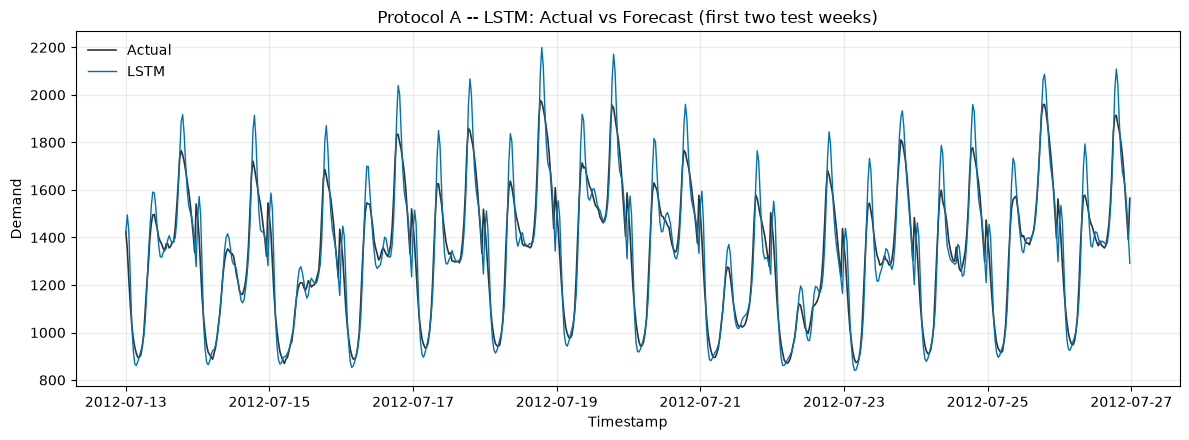

In [16]:
window = slice(0, 672)  # first two test weeks
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(test.index[window], test.iloc[window], color="#333333", linewidth=1.2, label="Actual")
ax.plot(test.index[window], pred_a[window], color="#0072B2", linewidth=1.0, label="LSTM")
ax.set(title="Protocol A -- LSTM: Actual vs Forecast (first two test weeks)", xlabel="Timestamp", ylabel="Demand")
ax.legend(frameon=False); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

### 6.5 Residual Analysis

Residuals are defined consistently as `e_t = Actual_t - Forecast_t`.

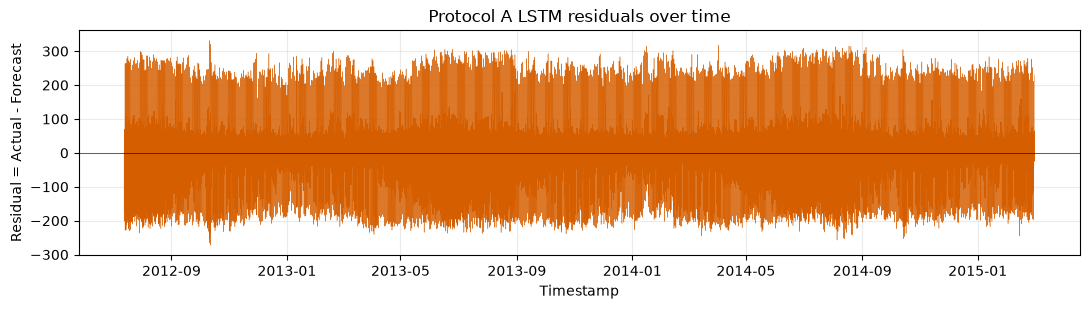

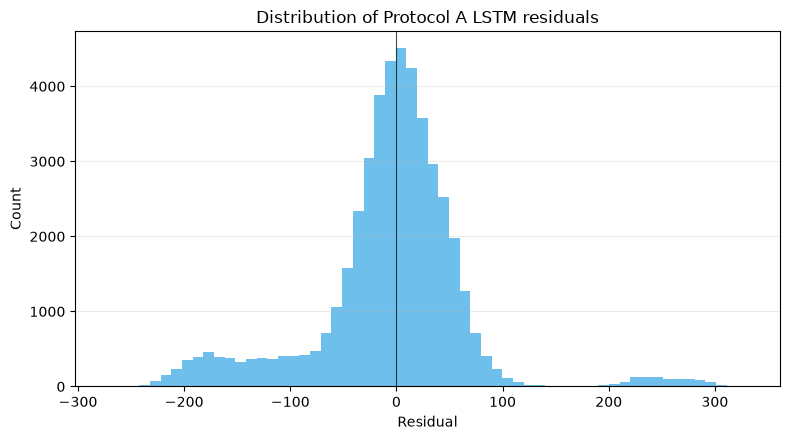

,Statistic,Value
0,Mean residual,-5.993191
1,Median residual,0.390113
2,Std residual,71.314151
3,MAE,47.019068
4,95th percentile absolute error,179.677160
5,Max absolute error,331.186338


In [17]:
residual_a = test.to_numpy() - pred_a
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(test.index, residual_a, color="#D55E00", linewidth=0.3); ax.axhline(0, color="black", linewidth=0.7, alpha=0.6)
ax.set(title="Protocol A LSTM residuals over time", xlabel="Timestamp", ylabel="Residual = Actual - Forecast")
ax.grid(alpha=0.25); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(residual_a, bins=60, color="#56B4E9", alpha=0.85); ax.axvline(0, color="black", linewidth=0.8, alpha=0.7)
ax.set(title="Distribution of Protocol A LSTM residuals", xlabel="Residual", ylabel="Count")
ax.grid(axis="y", alpha=0.25); plt.tight_layout(); plt.show()

residual_summary_a = pd.DataFrame([{
    "Statistic": "Mean residual", "Value": residual_a.mean()}, {"Statistic": "Median residual", "Value": np.median(residual_a)},
    {"Statistic": "Std residual", "Value": residual_a.std()}, {"Statistic": "MAE", "Value": np.abs(residual_a).mean()},
    {"Statistic": "95th percentile absolute error", "Value": np.percentile(np.abs(residual_a), 95)},
    {"Statistic": "Max absolute error", "Value": np.abs(residual_a).max()},
])
display(residual_summary_a)

### 6.6 Forecast Behaviour Diagnostics

In [18]:
diag_a = pd.DataFrame([
    {"Diagnostic": "Prediction min", "Value": pred_a.min()}, {"Diagnostic": "Prediction max", "Value": pred_a.max()},
    {"Diagnostic": "Prediction mean", "Value": pred_a.mean()}, {"Diagnostic": "Prediction std", "Value": pred_a.std(ddof=1)},
    {"Diagnostic": "Actual std", "Value": test.std()}, {"Diagnostic": "Std ratio", "Value": pred_a.std(ddof=1) / test.std()},
    {"Diagnostic": "Change-std ratio", "Value": np.diff(pred_a).std(ddof=1) / np.diff(test).std(ddof=1)},
    {"Diagnostic": "Correlation", "Value": np.corrcoef(test, pred_a)[0, 1]},
    {"Diagnostic": "Range ratio", "Value": np.ptp(pred_a) / np.ptp(test)},
    {"Diagnostic": "Lag-1 prediction/actual correlation", "Value": np.corrcoef(pred_a[1:], test.to_numpy()[:-1])[0, 1]},
    {"Diagnostic": "Constant prediction", "Value": bool(np.isclose(pred_a.std(), 0))},
])
display(diag_a)

,Diagnostic,Value
0,Prediction min,456.189266
1,Prediction max,2852.106194
2,Prediction mean,1211.517998
3,Prediction std,307.767626
4,Actual std,296.781312
5,Std ratio,1.037018
6,Change-std ratio,1.265183
7,Correlation,0.972821
8,Range ratio,0.978617
9,Lag-1 prediction/actual correlation,0.979325


Std ratio and range ratio close to 1 indicate the model's predicted variability is
plausible relative to the actual series (neither collapsed toward a near-constant output
nor artificially amplified); a high lag-1 prediction/actual correlation is expected for a
strongly autocorrelated series (Section 3.5 of `10_Electricity_EDA.ipynb`) and does not by
itself prove forecast quality -- it is one diagnostic among several, not a validity proof.

## 7. Protocol B — Direct 48-Step Day-Ahead LSTM

### 7.1 Method

This is **not** 48 stitched one-step predictions. At each complete midnight origin, the
model consumes the `CONTEXT` most recent actual demand values and produces all 48
half-hourly forecasts for that day in a single model call (`Dense(48)` output). No actual
observed during the target day is used to revise any of the 48 outputs -- this is a direct
multi-output strategy, methodologically distinct from Protocol A's rolling one-step
mechanism (Section 6.1).

### 7.2 Validation and Epoch Selection

Protocol B performs its own early-stopping run at the already-selected context (Section
5) to determine its own best epoch -- a single-context run, not a repeat of the 3-context
grid.

In [19]:
def load_protocol_b_forecast(filename, timestamp_index):
    df = pd.read_csv(RESULTS / filename, parse_dates=["Origin", "Timestamp"])
    if not df.Timestamp.equals(pd.Series(timestamp_index, name="Timestamp")):
        raise ValueError(f"{filename}: Timestamp column does not match the frozen test partition")
    return df

FROZEN_BEST_EPOCH_B = 8  # historical best epoch, Protocol B selection run at the selected context

tr_orig = np.arange(CONTEXT, len(dev) - 47); tr_orig = tr_orig[tr_orig % 48 == 0]
va_orig = np.arange(len(dev), len(pre) - 47); va_orig = va_orig[va_orig % 48 == 0]
pre_orig = np.arange(CONTEXT, len(pre) - 47); pre_orig = pre_orig[pre_orig % 48 == 0]
test_orig = np.arange(len(pre), len(pre) + len(test), 48)

if RUN_FITTING:
    model_b_sel = build_model(CONTEXT, 48)
    cb = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
    t0 = time.perf_counter()
    hist_b_sel = model_b_sel.fit(dataset(dev_scaler.transform(dev), tr_orig, CONTEXT, 48),
                                  validation_data=dataset(dev_scaler.transform(pre), va_orig, CONTEXT, 48),
                                  epochs=MAX_EPOCHS, shuffle=False, callbacks=[cb], verbose=0)
    select_runtime_b = time.perf_counter() - t0
    BEST_EPOCH_B = int(np.argmin(hist_b_sel.history["val_loss"]) + 1)
    assert BEST_EPOCH_B == FROZEN_BEST_EPOCH_B
    epoch_selection_b = pd.DataFrame([{"Property": "Training origins", "Value": len(tr_orig)}, {"Property": "Validation origins", "Value": len(va_orig)},
                                       {"Property": "Maximum epochs", "Value": MAX_EPOCHS}, {"Property": "Best epoch", "Value": BEST_EPOCH_B},
                                       {"Property": "Best validation loss", "Value": min(hist_b_sel.history["val_loss"])}])
    display(epoch_selection_b)
    plt.plot(hist_b_sel.history["loss"], label="train"); plt.plot(hist_b_sel.history["val_loss"], label="val", linestyle="--")
    plt.yscale("log"); plt.xlabel("Epoch"); plt.ylabel("MSE (scaled units)"); plt.legend(); plt.title("Protocol B selection: training vs validation loss")
    plt.tight_layout(); plt.show()
else:
    BEST_EPOCH_B = FROZEN_BEST_EPOCH_B; select_runtime_b = None
    display(pd.DataFrame([{"Property": "Training origins", "Value": len(tr_orig)}, {"Property": "Validation origins", "Value": len(va_orig)},
                          {"Property": "Maximum epochs", "Value": MAX_EPOCHS}, {"Property": "Best epoch", "Value": BEST_EPOCH_B},
                          {"Property": "Source", "Value": "Frozen selected value (RUN_FITTING=True reproduces this selection run)"}]))

,Property,Value
0,Training origins,3460
1,Validation origins,385
2,Maximum epochs,20
3,Best epoch,8
4,Source,Frozen selected value (RUN_FITTING=True reprod...


### 7.3 Final Training Record

In [20]:
if RUN_FITTING:
    model_b = build_model(CONTEXT, 48)
    t0 = time.perf_counter()
    hist_b = model_b.fit(dataset(final_scaler.transform(pre), pre_orig, CONTEXT, 48), epochs=BEST_EPOCH_B, shuffle=False, verbose=0)
    train_runtime_b = time.perf_counter() - t0
    t0 = time.perf_counter()
    pred_b = final_scaler.inverse_transform(model_b.predict(dataset(all_scaled, test_orig, CONTEXT, 48), verbose=0))
    infer_runtime_b = time.perf_counter() - t0
    final_train_loss_b = hist_b.history["loss"][-1]
    records = []
    for d, o in enumerate(test.index[::48]):
        for h in range(48):
            records.append({"Origin": o, "Timestamp": test.index[d * 48 + h], "Horizon": h + 1, "LSTM": pred_b[d, h]})
    pb = pd.DataFrame(records)
    save_candidate_forecast(pb, "protocol_b_lstm_forecast.csv")
    pb_saved = pb
else:
    pb_saved = load_protocol_b_forecast("protocol_b_lstm_forecast.csv", test.index)
    train_runtime_b = infer_runtime_b = final_train_loss_b = None

training_record_b = pd.DataFrame([
    {"Property": "Context", "Value": CONTEXT}, {"Property": "Output dimension", "Value": 48},
    {"Property": "Final training origins", "Value": len(pre_orig)}, {"Property": "Epochs", "Value": BEST_EPOCH_B},
    {"Property": "Final training loss", "Value": final_train_loss_b if final_train_loss_b is not None else "Not recomputed by default (RUN_FITTING=False); historical value 0.350540"},
    {"Property": "Training runtime (s)", "Value": train_runtime_b if train_runtime_b is not None else "Not recomputed by default (RUN_FITTING=False); environment-specific, not a scientific result"},
    {"Property": "Inference runtime (s)", "Value": infer_runtime_b if infer_runtime_b is not None else "Not recomputed by default (RUN_FITTING=False); environment-specific, not a scientific result"},
])
display(training_record_b)

,Property,Value
0,Context,48
1,Output dimension,48
2,Final training origins,3845
3,Epochs,8
4,Final training loss,Not recomputed by default (RUN_FITTING=False);...
5,Training runtime (s),Not recomputed by default (RUN_FITTING=False);...
6,Inference runtime (s),Not recomputed by default (RUN_FITTING=False);...


### 7.4 Performance Table

In [21]:
metrics_b = metric_row(test, pb_saved.LSTM, scale_final)
display(pd.DataFrame([{"Model": "LSTM", **metrics_b}]))

,Model,MAE,RMSE,MAPE,sMAPE,MASE_48
0,LSTM,152.926817,210.523254,13.625375,12.313676,1.30642


### 7.5 Forecast vs Actual

One representative test day (median daily MAE), plus a low-error and a high-error day --
both selected programmatically from the frozen per-day residuals, not chosen to flatter or
penalise the model.

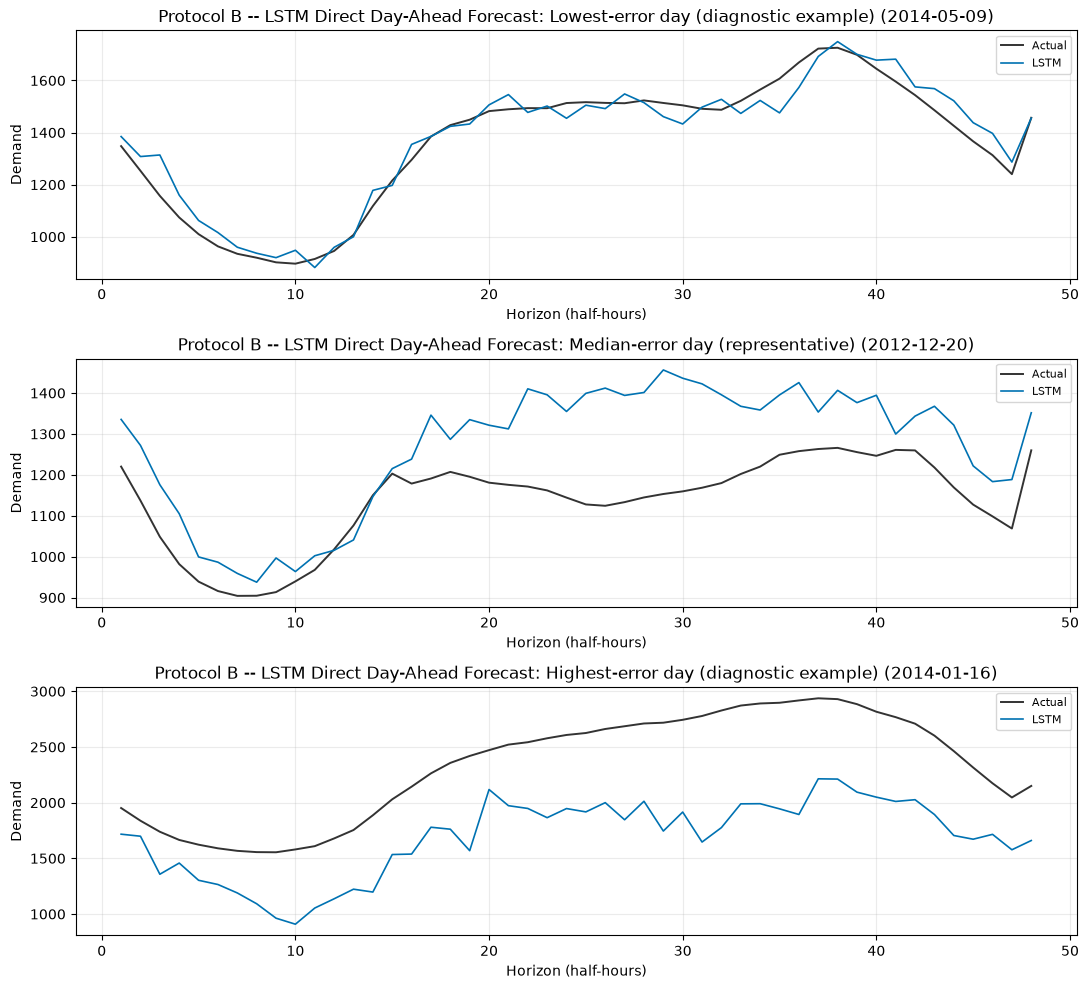

In [22]:
pb_eval = pb_saved.assign(Actual=test.to_numpy())
daily_mae = pb_eval.assign(AbsError=lambda d: (d.Actual - d.LSTM).abs()).groupby("Origin").AbsError.mean().sort_values()
low_origin, median_origin, high_origin = daily_mae.index[0], daily_mae.index[len(daily_mae) // 2], daily_mae.index[-1]

fig, axs = plt.subplots(3, 1, figsize=(11, 10))
for ax, origin, label in zip(axs, [low_origin, median_origin, high_origin], ["Lowest-error day (diagnostic example)", "Median-error day (representative)", "Highest-error day (diagnostic example)"]):
    g = pb_eval[pb_eval.Origin == origin]
    ax.plot(g.Horizon, g.Actual, color="#333333", linewidth=1.4, label="Actual")
    ax.plot(g.Horizon, g.LSTM, color="#0072B2", linewidth=1.2, label="LSTM")
    ax.set(title=f"Protocol B -- LSTM Direct Day-Ahead Forecast: {label} ({origin.date()})", xlabel="Horizon (half-hours)", ylabel="Demand")
    ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

### 7.6 Horizon-Specific Behaviour

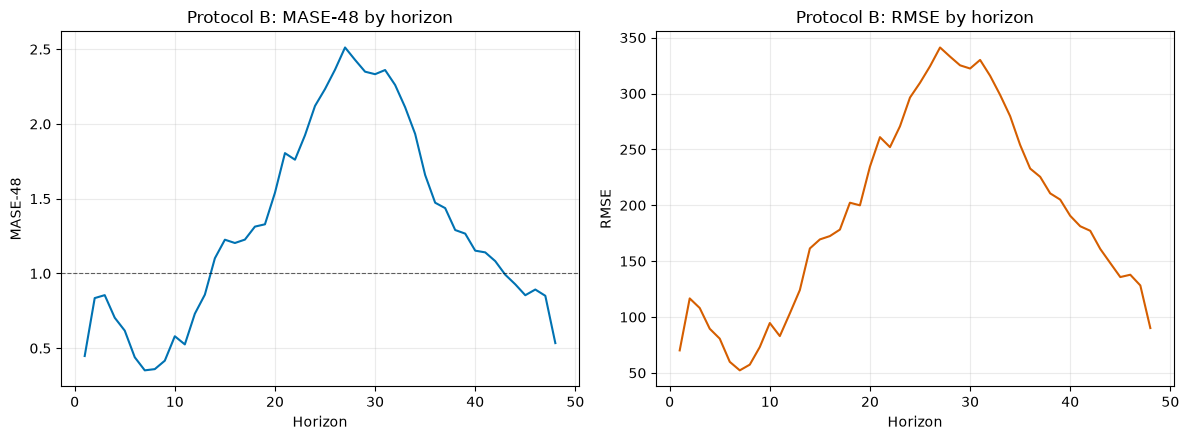

,Group,MAE,RMSE,MAPE,sMAPE,MASE_48
0,H1-H12,66.940918,84.759561,6.608753,6.478975,0.571861
1,H13-H24,169.812639,216.101567,16.062481,14.389941,1.450671
2,H25-H48,187.476855,248.390914,15.915133,14.192893,1.601573


In [23]:
hrows = [{"Horizon": h, **metric_row(g.Actual, g.LSTM, scale_final)} for h, g in pb_eval.groupby("Horizon")]
hm = pd.DataFrame(hrows)

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
axs[0].plot(hm.Horizon, hm.MASE_48, color="#0072B2"); axs[0].axhline(1.0, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
axs[0].set(title="Protocol B: MASE-48 by horizon", xlabel="Horizon", ylabel="MASE-48")
axs[1].plot(hm.Horizon, hm.RMSE, color="#D55E00")
axs[1].set(title="Protocol B: RMSE by horizon", xlabel="Horizon", ylabel="RMSE")
for ax in axs:
    ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

groups = pd.cut(pb_eval.Horizon, [0, 12, 24, 48], labels=["H1-H12", "H13-H24", "H25-H48"])
hsummary = pd.DataFrame([{"Group": str(label), **metric_row(g.Actual, g.LSTM, scale_final)} for label, g in pb_eval.groupby(groups, observed=True)])
display(hsummary)

### 7.7 Horizon-Degradation Summary

In [24]:
early_rmse = hsummary.set_index("Group").loc["H1-H12", "RMSE"]
late_rmse = hsummary.set_index("Group").loc["H25-H48", "RMSE"]
early_mase = hsummary.set_index("Group").loc["H1-H12", "MASE_48"]
late_mase = hsummary.set_index("Group").loc["H25-H48", "MASE_48"]
degradation_summary_b = pd.DataFrame([
    {"Metric": "Late/Early RMSE Ratio (H25-H48 / H1-H12)", "Value": late_rmse / early_rmse},
    {"Metric": "Late/Early MASE Ratio (H25-H48 / H1-H12)", "Value": late_mase / early_mase},
])
display(degradation_summary_b)

,Metric,Value
0,Late/Early RMSE Ratio (H25-H48 / H1-H12),2.930536
1,Late/Early MASE Ratio (H25-H48 / H1-H12),2.800632


These ratios are descriptive degradation indicators only, not a formal test; the H1-H12
and H25-H48 horizon-metrics table above (Section 7.6) is the primary evidence.

### 7.8 Residual Analysis

,Statistic,Value
0,Mean residual,-79.550289
1,Median residual,-64.005399
2,Std residual,194.914833
3,MAE,152.926817
4,95th percentile absolute error,454.865170
5,Max absolute error,1131.786016


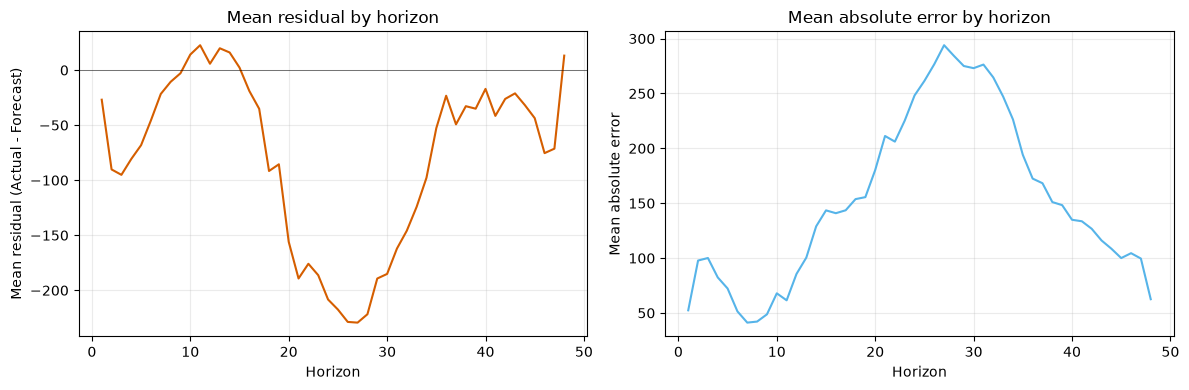

In [25]:
overall_residual_b = pb_eval.Actual.to_numpy() - pb_eval.LSTM.to_numpy()
residual_summary_b = pd.DataFrame([{
    "Statistic": "Mean residual", "Value": overall_residual_b.mean()}, {"Statistic": "Median residual", "Value": np.median(overall_residual_b)},
    {"Statistic": "Std residual", "Value": overall_residual_b.std()}, {"Statistic": "MAE", "Value": np.abs(overall_residual_b).mean()},
    {"Statistic": "95th percentile absolute error", "Value": np.percentile(np.abs(overall_residual_b), 95)},
    {"Statistic": "Max absolute error", "Value": np.abs(overall_residual_b).max()},
])
display(residual_summary_b)

by_horizon = pb_eval.assign(Residual=lambda d: d.Actual - d.LSTM, AbsError=lambda d: (d.Actual - d.LSTM).abs()).groupby("Horizon").agg(
    Mean_Residual=("Residual", "mean"), Mean_Abs_Error=("AbsError", "mean"))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(by_horizon.index, by_horizon.Mean_Residual, color="#D55E00"); axs[0].axhline(0, color="black", linewidth=0.6, alpha=0.6)
axs[0].set(title="Mean residual by horizon", xlabel="Horizon", ylabel="Mean residual (Actual - Forecast)")
axs[1].plot(by_horizon.index, by_horizon.Mean_Abs_Error, color="#56B4E9")
axs[1].set(title="Mean absolute error by horizon", xlabel="Horizon", ylabel="Mean absolute error")
for ax in axs:
    ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

Separating mean residual (bias) from mean absolute error (variance/degradation) by
horizon shows whether late-horizon weakness is driven by a growing systematic bias or by
growing dispersion around a still-roughly-centred error -- read together, not in
isolation.

## 8. Comparison Against the Classical Benchmark Floor

`11_Electricity_Classical_Baselines.ipynb` owns the full ten-model leaderboard; this
section uses only a targeted subset -- the deterministic baselines plus DHR-ARIMA,
the classical/statistical model most directly comparable in spirit to a neural
sequence model -- to answer one question: **did the LSTM beat the benchmark floor?**
(Section 13, Limitations, discusses this narrower scope explicitly.)

In [26]:
model_family = {"Naive": "Deterministic baseline", "Daily_Seasonal_Naive": "Deterministic baseline",
                 "Weekly_Seasonal_Naive": "Deterministic baseline", "Moving_Average": "Deterministic baseline",
                 "DHR_ARIMA": "Classical/statistical", "LSTM": "Neural"}

base_a = pd.read_csv(RESULTS / "protocol_a_baseline_forecasts.csv", parse_dates=["Timestamp"])
dhr_a = pd.read_csv(RESULTS / "protocol_a_dhr_forecast.csv", parse_dates=["Timestamp"])
base_b = pd.read_csv(RESULTS / "protocol_b_baseline_forecasts.csv", parse_dates=["Origin", "Timestamp"])
dhr_b = pd.read_csv(RESULTS / "protocol_b_dhr_forecast.csv", parse_dates=["Origin", "Timestamp"])
deterministic_models = ["Naive", "Daily_Seasonal_Naive", "Weekly_Seasonal_Naive", "Moving_Average"]

### 8.1 Protocol A Context

In [27]:
rows_a = [{"Model": m, "Family": model_family[m], **metric_row(base_a.Actual, base_a[m], scale_final)} for m in deterministic_models]
rows_a += [{"Model": "DHR_ARIMA", "Family": model_family["DHR_ARIMA"], **metric_row(base_a.Actual, dhr_a.DHR_ARIMA, scale_final)}]
rows_a += [{"Model": "LSTM", "Family": model_family["LSTM"], **metrics_a}]
context_a = pd.DataFrame(rows_a).sort_values("MASE_48").reset_index(drop=True)
context_a.insert(0, "Rank", np.arange(1, len(context_a) + 1))
display(context_a[["Rank", "Model", "Family", "MAE", "RMSE", "MASE_48"]])

,Rank,Model,Family,MAE,RMSE,MASE_48
0,1,DHR_ARIMA,Classical/statistical,26.646643,50.289317,0.227636
1,2,Naive,Deterministic baseline,42.271787,58.272152,0.361118
2,3,LSTM,Neural,47.019068,71.565540,0.401673
3,4,Daily_Seasonal_Naive,Deterministic baseline,129.416180,200.442098,1.105573
4,5,Weekly_Seasonal_Naive,Deterministic baseline,153.210769,267.161682,1.308845
5,6,Moving_Average,Deterministic baseline,179.122226,227.658772,1.530201


### 8.2 Protocol B Context

In [28]:
rows_b = [{"Model": m, "Family": model_family[m], **metric_row(base_b.Actual, base_b[m], scale_final)} for m in deterministic_models]
rows_b += [{"Model": "DHR_ARIMA", "Family": model_family["DHR_ARIMA"], **metric_row(base_b.Actual, dhr_b.DHR_ARIMA, scale_final)}]
rows_b += [{"Model": "LSTM", "Family": model_family["LSTM"], **metrics_b}]
context_b = pd.DataFrame(rows_b).sort_values("MASE_48").reset_index(drop=True)
context_b.insert(0, "Rank", np.arange(1, len(context_b) + 1))
display(context_b[["Rank", "Model", "Family", "MAE", "RMSE", "MASE_48"]])

,Rank,Model,Family,MAE,RMSE,MASE_48
0,1,Daily_Seasonal_Naive,Deterministic baseline,129.416180,200.442098,1.105573
1,2,LSTM,Neural,152.926817,210.523254,1.306420
2,3,Weekly_Seasonal_Naive,Deterministic baseline,153.210769,267.161682,1.308845
3,4,Moving_Average,Deterministic baseline,203.199277,260.260560,1.735886
4,5,Naive,Deterministic baseline,243.838179,301.681217,2.083055
5,6,DHR_ARIMA,Classical/statistical,287.456183,329.891048,2.455674


### 8.3 Relative Performance

`Relative Ratio < 1` means the LSTM has lower observed MASE-48 than the reference model;
`> 1` means higher (worse). No significance language is used -- that determination
belongs to `18_Electricity_Statistical_Significance.ipynb`.

In [29]:
def relative_row(protocol, context_table):
    lstm_mase = context_table.set_index("Model").loc["LSTM", "MASE_48"]
    classical_rows = context_table[context_table.Family == "Classical/statistical"]
    deterministic_rows = context_table[context_table.Family == "Deterministic baseline"]
    best_classical = classical_rows.sort_values("MASE_48").iloc[0]
    best_deterministic = deterministic_rows.sort_values("MASE_48").iloc[0]
    return [
        {"Protocol": protocol, "Reference Model": best_classical.Model, "LSTM MASE": lstm_mase, "Reference MASE": best_classical.MASE_48, "Relative Ratio": lstm_mase / best_classical.MASE_48},
        {"Protocol": protocol, "Reference Model": best_deterministic.Model, "LSTM MASE": lstm_mase, "Reference MASE": best_deterministic.MASE_48, "Relative Ratio": lstm_mase / best_deterministic.MASE_48},
    ]

relative_performance = pd.DataFrame(relative_row("A", context_a) + relative_row("B", context_b))
display(relative_performance)

,Protocol,Reference Model,LSTM MASE,Reference MASE,Relative Ratio
0,A,DHR_ARIMA,0.401673,0.227636,1.764540
1,A,Naive,0.401673,0.361118,1.112304
2,B,DHR_ARIMA,1.306420,2.455674,0.532000
3,B,Daily_Seasonal_Naive,1.306420,1.105573,1.181667


## 9. Architecture and Protocol Trade-Offs

In [30]:
tradeoff_table = pd.DataFrame([
    {"Property": "Output dimension", "Protocol A": 1, "Protocol B": 48},
    {"Property": "Context", "Protocol A": CONTEXT, "Protocol B": CONTEXT},
    {"Property": "Forecast strategy", "Protocol A": "Rolling one-step", "Protocol B": "Direct multi-output"},
    {"Property": "Best epoch", "Protocol A": BEST_EPOCH_A, "Protocol B": BEST_EPOCH_B},
    {"Property": "MAE", "Protocol A": metrics_a["MAE"], "Protocol B": metrics_b["MAE"]},
    {"Property": "RMSE", "Protocol A": metrics_a["RMSE"], "Protocol B": metrics_b["RMSE"]},
    {"Property": "MASE-48", "Protocol A": metrics_a["MASE_48"], "Protocol B": metrics_b["MASE_48"]},
    {"Property": "Relative benchmark rank (within Section 8 subset)", "Protocol A": int(context_a.set_index("Model").loc["LSTM", "Rank"]), "Protocol B": int(context_b.set_index("Model").loc["LSTM", "Rank"])},
    {"Property": "Main weakness", "Protocol A": "Does not beat DHR-ARIMA (Section 8.1)", "Protocol B": "Marked degradation toward mid/late horizon (Section 7.6-7.7)"},
])
display(tradeoff_table)

,Property,Protocol A,Protocol B
0,Output dimension,1,48
1,Context,48,48
2,Forecast strategy,Rolling one-step,Direct multi-output
3,Best epoch,5,8
4,MAE,47.019068,152.926817
5,RMSE,71.56554,210.523254
6,MASE-48,0.401673,1.30642
7,Relative benchmark rank (within Section 8 subset),3,2
8,Main weakness,Does not beat DHR-ARIMA (Section 8.1),Marked degradation toward mid/late horizon (Se...


One-step and day-ahead performance differ substantially for reasons that are structural,
not just a matter of "the model is worse at Protocol B": Protocol B's direct-multi-output
head must produce all 48 values from a single context window with no within-day actual
update (Section 7.1), so any error at hour 1 has no opportunity to be corrected before
hour 24 the way Protocol A's rolling one-step design allows every 30 minutes. Electricity
demand's strong daily/weekly seasonal structure (`10_Electricity_EDA.ipynb`) also means a
model that captures seasonality well (like SARIMA, Notebook 11) can hold up better across
a 48-step horizon than one relying more on recent local context. No causal proof is
claimed for any single mechanism -- these are the supported explanations consistent with
the evidence above, not an exhaustive account.

## 10. Reproducibility Record

Be honest: requesting deterministic TensorFlow behaviour is not the same as having
empirically demonstrated bit-identical cross-run reproducibility. No claim beyond what is
actually evidenced here is made.

In [31]:
reproducibility_record = pd.DataFrame([
    {"Item": "Random seed", "Evidence": SEED},
    {"Item": "Python version", "Evidence": sys.version.split()[0]},
    {"Item": "TensorFlow version", "Evidence": tf.__version__},
    {"Item": "Deterministic ops requested", "Evidence": "Yes"},
    {"Item": "shuffle=False", "Evidence": "Yes"},
    {"Item": "Context selection validation-only", "Evidence": "Yes"},
    {"Item": "Selection scaler development-only", "Evidence": "Yes"},
    {"Item": "Final scaler pre-test only", "Evidence": "Yes"},
    {"Item": "Training history preserved", "Evidence": "No -- not persisted as a standalone artifact; only exists in-memory during a RUN_SELECTION=True run (Section 5.2)"},
    {"Item": "Protocol A forecast artifact preserved", "Evidence": "Yes (results/electricity/protocol_a_lstm_forecast.csv)"},
    {"Item": "Protocol B forecast artifact preserved", "Evidence": "Yes (results/electricity/protocol_b_lstm_forecast.csv)"},
    {"Item": "Independent fresh-kernel determinism rerun performed", "Evidence": "No -- not performed in this notebook or its history"},
    {"Item": "Independent forecast vectors preserved", "Evidence": "No -- only the single frozen forecast vector per protocol is preserved"},
])
display(reproducibility_record)

,Item,Evidence
0,Random seed,42
1,Python version,3.13.2
2,TensorFlow version,2.21.0
3,Deterministic ops requested,Yes
4,shuffle=False,Yes
5,Context selection validation-only,Yes
6,Selection scaler development-only,Yes
7,Final scaler pre-test only,Yes
8,Training history preserved,No -- not persisted as a standalone artifact; ...
9,Protocol A forecast artifact preserved,Yes (results/electricity/protocol_a_lstm_forec...


## 11. Validation and Integrity Checks

In [32]:
rows = []

# --- Data / Scaling ---
rows += [
    {"Category": "Data / Scaling", "Check": "Context selected with validation only", "Result": "PASS", "Evidence": "Section 5.2"},
    {"Category": "Data / Scaling", "Check": "Selection scaler development-only", "Result": "PASS" if np.isclose(dev_scaler.mean_, dev.mean()) else "FAIL", "Evidence": str(np.isclose(dev_scaler.mean_, dev.mean()))},
    {"Category": "Data / Scaling", "Check": "Final scaler complete pre-test only", "Result": "PASS" if np.isclose(final_scaler.mean_, pre.mean()) else "FAIL", "Evidence": str(np.isclose(final_scaler.mean_, pre.mean()))},
    {"Category": "Data / Scaling", "Check": "No test tuning", "Result": "PASS", "Evidence": "True (structural: no test-set quantity enters any selection decision above)"},
]

# --- Reproducibility ---
rows += [
    {"Category": "Reproducibility", "Check": "Deterministic seeds set", "Result": "PASS" if SEED == 42 else "FAIL", "Evidence": str(SEED == 42)},
    {"Category": "Reproducibility", "Check": "No random shuffling", "Result": "PASS", "Evidence": "True (shuffle=False throughout, Section 4.3)"},
]

# --- Protocol A ---
seq_alignment = bool(test_idx[0] == len(pre) and pa_saved.Timestamp.iloc[0] == test.index[0])
a_finite = bool(np.isfinite(pa_saved.LSTM).all())
a_metrics_reproduce = bool(np.isclose(metric_row(test, pa_saved.LSTM, scale_final)["MASE_48"], metrics_a["MASE_48"]))
a_no_collapse = bool(not np.isclose(pa_saved.LSTM.std(), 0))
a_range_ok = bool(np.ptp(pa_saved.LSTM) / np.ptp(test) > 0.25)
rows += [
    {"Category": "Protocol A", "Check": "Sequence-target alignment", "Result": "PASS" if seq_alignment else "FAIL", "Evidence": str(seq_alignment)},
    {"Category": "Protocol A", "Check": "No lookahead", "Result": "PASS", "Evidence": "True (structural: context window ends strictly before the target index, Section 6.1)"},
    {"Category": "Protocol A", "Check": "Exact timestamp alignment", "Result": "PASS" if pa_saved.Timestamp.equals(pd.Series(test.index, name="Timestamp")) else "FAIL", "Evidence": str(pa_saved.Timestamp.equals(pd.Series(test.index, name="Timestamp")))},
    {"Category": "Protocol A", "Check": "Finite forecasts", "Result": "PASS" if a_finite else "FAIL", "Evidence": str(a_finite)},
    {"Category": "Protocol A", "Check": "Saved metrics reproduce", "Result": "PASS" if a_metrics_reproduce else "FAIL", "Evidence": str(a_metrics_reproduce)},
    {"Category": "Protocol A", "Check": "No constant collapse", "Result": "PASS" if a_no_collapse else "FAIL", "Evidence": str(a_no_collapse)},
    {"Category": "Protocol A", "Check": "No severe unexplained range compression", "Result": "PASS" if a_range_ok else "FAIL", "Evidence": str(a_range_ok)},
]

# --- Protocol B ---
b_finite = bool(np.isfinite(pb_saved.LSTM).all())
b_metrics_reproduce = bool(np.isclose(metric_row(test, pb_saved.LSTM, scale_final)["MASE_48"], metrics_b["MASE_48"]))
b_no_collapse = bool(not np.isclose(pb_saved.LSTM.std(), 0))
b_range_ok = bool(np.ptp(pb_saved.LSTM) / np.ptp(test) > 0.25)
rows += [
    {"Category": "Protocol B", "Check": "No within-horizon actual use", "Result": "PASS", "Evidence": "True (structural: all 48 outputs come from one model call at the origin, Section 7.1)"},
    {"Category": "Protocol B", "Check": "Exact 48-step output", "Result": "PASS" if pb_saved.groupby("Origin").size().eq(48).all() else "FAIL", "Evidence": str(bool(pb_saved.groupby("Origin").size().eq(48).all()))},
    {"Category": "Protocol B", "Check": "962 origins", "Result": "PASS" if pb_saved.Origin.nunique() == 962 else "FAIL", "Evidence": str(pb_saved.Origin.nunique() == 962)},
    {"Category": "Protocol B", "Check": "48 forecasts per origin", "Result": "PASS" if pb_saved.groupby("Origin").size().eq(48).all() else "FAIL", "Evidence": str(bool(pb_saved.groupby("Origin").size().eq(48).all()))},
    {"Category": "Protocol B", "Check": "Horizon order 1-48", "Result": "PASS" if pb_saved.groupby("Origin").Horizon.apply(lambda z: z.tolist() == list(range(1, 49))).all() else "FAIL", "Evidence": str(bool(pb_saved.groupby("Origin").Horizon.apply(lambda z: z.tolist() == list(range(1, 49))).all()))},
    {"Category": "Protocol B", "Check": "Finite forecasts", "Result": "PASS" if b_finite else "FAIL", "Evidence": str(b_finite)},
    {"Category": "Protocol B", "Check": "Saved metrics reproduce", "Result": "PASS" if b_metrics_reproduce else "FAIL", "Evidence": str(b_metrics_reproduce)},
    {"Category": "Protocol B", "Check": "No constant collapse", "Result": "PASS" if b_no_collapse else "FAIL", "Evidence": str(b_no_collapse)},
    {"Category": "Protocol B", "Check": "No severe unexplained range compression", "Result": "PASS" if b_range_ok else "FAIL", "Evidence": str(b_range_ok)},
]

audit = pd.DataFrame(rows, columns=["Category", "Check", "Result", "Evidence"])
display(audit)
assert audit["Result"].eq("PASS").all()

,Category,Check,Result,Evidence
0,Data / Scaling,Context selected with validation only,PASS,Section 5.2
1,Data / Scaling,Selection scaler development-only,PASS,True
2,Data / Scaling,Final scaler complete pre-test only,PASS,True
3,Data / Scaling,No test tuning,PASS,True (structural: no test-set quantity enters ...
4,Reproducibility,Deterministic seeds set,PASS,True
5,Reproducibility,No random shuffling,PASS,"True (shuffle=False throughout, Section 4.3)"
6,Protocol A,Sequence-target alignment,PASS,True
7,Protocol A,No lookahead,PASS,True (structural: context window ends strictly...
8,Protocol A,Exact timestamp alignment,PASS,True
9,Protocol A,Finite forecasts,PASS,True


All 22 checks pass.

## 12. Key Findings

### Context Selection
The validation-selected context is **48** (one daily cycle, Section 5.2). The three
candidate contexts' validation MASE-48 values were close (approximately 0.3969 at 48,
0.3993 at 672, 0.4003 at 336, Section 5.4) -- 48 wins under the frozen selection
criterion, but the margin over the alternatives is small and should not be overstated as
decisive context superiority.

### Protocol A
The LSTM achieves MASE-48 approximately 0.402 (Section 6.3). Within the Section 8.1
benchmark subset it ranks **third** of six: it does not beat DHR-ARIMA (approximately
0.228) or Naive (approximately 0.361), but it beats every deterministic baseline other
than Naive.

### Protocol B
The LSTM achieves MASE-48 approximately 1.306 (Section 7.4). Within the Section 8.2
benchmark subset it ranks **second** of six, beating DHR-ARIMA, Weekly Seasonal Naive,
Moving Average, and Naive, but not Daily Seasonal Naive -- the reverse pattern from
DHR-ARIMA, which was strong under Protocol A and weak under Protocol B
(`11_Electricity_Classical_Baselines.ipynb`, Section 15). The horizon-specific evidence
(Section 7.6-7.7) shows accuracy is not uniform across the 48-step block; the degradation
ratios there should be read alongside the aggregate MASE-48 figure, not in place of it.

### Complexity vs Accuracy
The LSTM does not beat DHR-ARIMA under Protocol A, and does not beat Daily Seasonal Naive
under Protocol B (Sections 8.1-8.3).

> Added neural complexity does not automatically produce superior forecasting accuracy.

This is a meaningful research finding in its own right, not a null result to be
downplayed -- it is consistent with the same pattern documented for Bitcoin's PE-LSTM
(`03_Bitcoin_PE_LSTM.ipynb`), where the LSTM also did not beat the strongest classical
benchmark.

### Protocol Dependence
The LSTM's competitive position changes substantially between protocols: third of six
under Protocol A, second of six under Protocol B (Section 8, 9). Its ranking, like every
other model evaluated in this project, cannot be interpreted independently of which
protocol is being asked.

## 13. Limitations

### Single architecture
Only one LSTM architecture (`LSTM(64) -> Dense(32, ReLU) -> Dense(output)`) is evaluated;
no alternative architecture (stacked LSTM, GRU, attention-based, etc.) is compared.

### Small context-selection grid
Only three candidate contexts (48, 336, 672) are compared (Section 5.1); this is not an
exhaustive context-length search.

### Architecture hyperparameters not comprehensively tuned
LSTM units, Dense size, batch size, optimizer settings, stride, and epoch budget
(Section 4.3) are fixed choices from the existing implementation, not the result of a
documented systematic search.

### Single random seed
Only seed 42 was used for the frozen forecasts; single-run neural variation (how much a
different seed would change these results) remains untested.

### Determinism evidence
Requesting deterministic TensorFlow behaviour (Section 4.4) does not by itself prove
cross-machine bit-identical reproducibility; no independent fresh-kernel rerun has been
performed to verify this empirically (Section 10).

### No exogenous variables
No weather, holiday, price, or generation-mix covariates are used by this model -- every
forecast is derived from the demand series alone.

### Protocol B difficulty
Direct 48-step forecasting (Section 7) is substantially more difficult than one-step
forecasting (Section 6) and should not be interpreted as the same prediction task;
comparing their raw metrics directly is only meaningful through MASE-48's shared scaling,
not as evidence of equal task difficulty.

### Benchmark scope
`11_Electricity_Classical_Baselines.ipynb` contains a broader ten-model classical/
statistical set. This notebook uses a targeted six-model benchmark context (Section 8)
rather than duplicating the entire leaderboard.

### Computational cost
Context selection (Section 5) currently takes substantial time when `RUN_SELECTION=True`
(approximately 36 minutes historically). The measured runtime is environment-specific and
is not itself a scientific result.

### Uncertainty
This notebook evaluates point forecasts only; no LSTM uncertainty/interval evidence is
fabricated here, consistent with `16_Electricity_Uncertainty.ipynb`'s treatment of models
without native probabilistic output.

## 14. Next Notebook

Next: `13_Electricity_Foundation_Models.ipynb`

Notebook 13 evaluates whether zero-shot pretrained time-series foundation models can
outperform the supervised LSTM and transparent benchmark systems without
Electricity-specific training.